# Clip v2 (maybe I'll be less confused)

In [1]:
from torch.utils.data import DataLoader
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [2]:
import os
from dataset import VOC_CLASSES, WSSSDataset, wsss_collate_fn, make_transform, make_voc_datasets


batch_size = 16
num_workers = min(4, os.cpu_count() or 1)

voc_segmentation, voc_val = make_voc_datasets()

# We define TWO dataloaders. One sequential (for caching), one shuffled (for training).
seq_dataloader = DataLoader(voc_segmentation, batch_size=batch_size, collate_fn=wsss_collate_fn, shuffle=False, num_workers=num_workers, pin_memory=True)
dataloader = DataLoader(voc_segmentation, batch_size=batch_size, collate_fn=wsss_collate_fn, shuffle=True, num_workers=num_workers, pin_memory=True)

print(f"Dataset contains {len(voc_segmentation)} images configued across {num_workers} parallel workers.")

Dataset contains 1464 images configued across 4 parallel workers.


## Step 1: Using CLIP-ES to create labeled CAMs. 

The first stage of our pipeline is [CLIP-ES (CVPR 2023)](https://github.com/linyq2117/CLIP-ES).

The way clip works is that it uses a frozen CLIP ViT-B/16 plus Grad-CAM hooked into the last attention block. 
This turns image-level labels into CAMs. The CAMs are then refined by class-aware attention affinity (CAA)
using the model's self attention. 

In [3]:
import sys
import os

CLIP_ES_DIR = os.path.abspath("clip_es")

if CLIP_ES_DIR not in sys.path:
    sys.path.insert(0, CLIP_ES_DIR)

# we import clip directly from clip_es directory. 
# the clip-es repo also contained its own version of openai-clip, so we will use that. 
import clip
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import scale_cam_image

# clip uses its own categories
from clip_text import (
    BACKGROUND_CATEGORY,
    class_names,
    new_class_names,
)
from utils import parse_xml_to_dict, scoremap2bbox

import generate_cams_voc12 as ces
from generate_cams_voc12 import (
    zeroshot_classifier,
    reshape_transform,
    ClipOutputTarget,
    _transform_resize,
)

# clip-es has its own classes for better segmentation. 
print("Foreground classes :", new_class_names)
print("Background classes :", BACKGROUND_CATEGORY)

/Users/anthony/Code/cs484-wsss/clip_es/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


Foreground classes : ['aeroplane', 'bicycle', 'bird avian', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair seat', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person with clothes,people,human', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor screen']
Background classes : ['ground', 'land', 'grass', 'tree', 'building', 'wall', 'sky', 'lake', 'water', 'river', 'sea', 'railway', 'railroad', 'keyboard', 'helmet', 'cloud', 'house', 'mountain', 'ocean', 'road', 'rock', 'street', 'valley', 'bridge', 'sign']


In [4]:
import torch
if torch.cuda.is_available():
    clip_device = "cuda"
elif torch.backends.mps.is_available():
    clip_device = "cpu"
else:
    clip_device = "cpu"

CLIP_MODEL_NAME = "ViT-B/16"
print(f"Loading CLIP-ES on {CLIP_MODEL_NAME}")
clip_model, _ = clip.load(CLIP_MODEL_NAME, device=clip_device)
clip_model.eval()
print("CLIP loaded")
ces.device = clip_device

PROMPT_TEMPLATES = ["a clean origami {}."]
fg_text_features = zeroshot_classifier(new_class_names,    PROMPT_TEMPLATES, clip_model) # from clip-es
bg_text_features = zeroshot_classifier(BACKGROUND_CATEGORY, PROMPT_TEMPLATES, clip_model)

Loading CLIP-ES on ViT-B/16
CLIP loaded


In [5]:
import numpy as np
import cv2
from PIL import Image

# clip-es design choice
target_layers = [clip_model.visual.transformer.resblocks[-1].ln_1]
cam = GradCAM(
    model=clip_model,
    target_layers=target_layers,
    reshape_transform=reshape_transform,
)

Running CLIP-ES on 2007_000032...
Predicted classes (label ids): [0, 14]


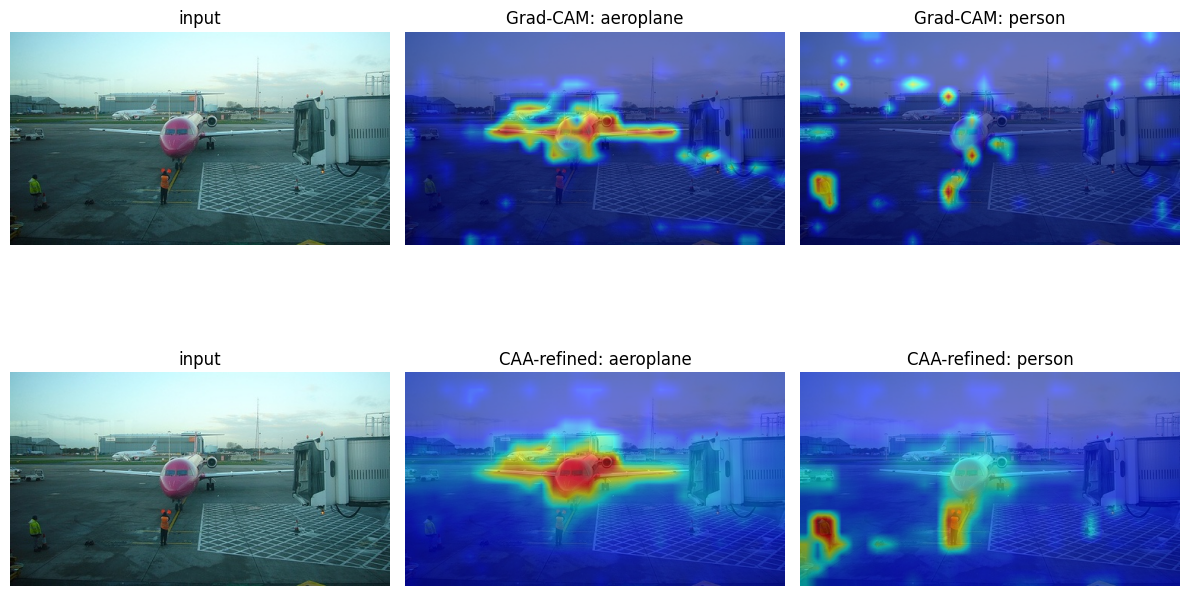

In [6]:
import matplotlib.pyplot as plt
from lxml import etree

VOC_ROOT = "data/VOCdevkit/VOC2012"
PATCH = 16


def run_clip_es_on_image(image_id):
    """Run CLIP-ES end-to-end on one VOC image and return the refined CAMs.
    This is a re-implementation of the original code. Much is copied.
    """
    img_path = os.path.join(VOC_ROOT, "JPEGImages", f"{image_id}.jpg")
    xml_path = os.path.join(VOC_ROOT, "Annotations", f"{image_id}.xml")

    with open(xml_path) as f:
        data = parse_xml_to_dict(etree.fromstring(f.read()))["annotation"]
    ori_W, ori_H = int(data["size"]["width"]), int(data["size"]["height"])
    present_names = []
    for obj in data["object"]:
        if obj["name"] not in present_names:
            present_names.append(obj["name"])

    label_id_list = [class_names.index(n) for n in present_names]
    if not label_id_list:
        raise RuntimeError(f"{image_id} has no labeled objects")

    h = int(np.ceil(ori_H / PATCH) * PATCH)
    w = int(np.ceil(ori_W / PATCH) * PATCH)
    image = _transform_resize(h, w)(Image.open(img_path)).unsqueeze(0).to(clip_device)
    image_features, attn_weight_list = clip_model.encode_image(image, h, w)

    fg_temp = fg_text_features[label_id_list]
    text_temp = torch.cat([fg_temp, bg_text_features], dim=0).to(clip_device)
    cam_input = [image_features, text_temp, h, w]

    coarse_cams = {}
    refined_cams = {}
    for col_idx, class_idx in enumerate(label_id_list):
        targets = [ClipOutputTarget(col_idx)]
        grayscale_cam, _logits, attn_weight_last = cam(
            input_tensor=cam_input, targets=targets, target_size=None
        )
        grayscale_cam = grayscale_cam[0]
        coarse_cams[class_idx] = cv2.resize(grayscale_cam, (ori_W, ori_H))

        all_attn = attn_weight_list + [attn_weight_last]
        attn = torch.stack([a[:, 1:, 1:] for a in all_attn], dim=0)[-8:]
        attn = attn.mean(dim=0)[0].detach().float().cpu()

        boxes, n_box = scoremap2bbox(grayscale_cam, threshold=0.4, multi_contour_eval=True)
        aff_mask = torch.zeros(grayscale_cam.shape)
        for i in range(n_box):
            x0, y0, x1, y1 = boxes[i]
            aff_mask[y0:y1, x0:x1] = 1
        aff_mask = aff_mask.view(1, -1)

        trans = attn / attn.sum(dim=0, keepdim=True)
        trans = trans / trans.sum(dim=1, keepdim=True)
        for _ in range(2):
            trans = trans / trans.sum(dim=0, keepdim=True)
            trans = trans / trans.sum(dim=1, keepdim=True)
        trans = (trans + trans.T) / 2
        trans = trans @ trans
        trans = trans * aff_mask

        refined = trans @ torch.tensor(grayscale_cam).view(-1, 1)
        refined = refined.view(h // PATCH, w // PATCH).numpy().astype(np.float32)
        refined_cams[class_idx] = scale_cam_image([refined], (ori_W, ori_H))[0]

    n_fg = len(fg_temp)
    bg_cam_per_cat = {}
    for bg_local_idx in range(len(bg_text_features)):
        targets = [ClipOutputTarget(n_fg + bg_local_idx)]
        grayscale_cam, _, _ = cam(
            input_tensor=cam_input, targets=targets, target_size=None
        )
        bg_cam_per_cat[BACKGROUND_CATEGORY[bg_local_idx]] = cv2.resize(
            grayscale_cam[0], (ori_W, ori_H)
        )
    bg_cam = np.maximum.reduce(list(bg_cam_per_cat.values()))
    if bg_cam.max() > 0:
        bg_cam = bg_cam / bg_cam.max()

    return {
        "image_path": img_path,
        "image_size": (ori_W, ori_H),
        "labels": label_id_list,
        "coarse": coarse_cams,
        "refined": refined_cams,
        "bg_cam": bg_cam.astype(np.float32),
        "bg_per_cat": bg_cam_per_cat,
    }


def show_cams(result, alpha=0.55):
    img = np.array(Image.open(result["image_path"]).convert("RGB"))
    n = len(result["labels"])
    fig, axes = plt.subplots(2, n + 1, figsize=(4 * (n + 1), 8))
    if n == 1:
        axes = axes.reshape(2, 2)
    axes[0, 0].imshow(img); axes[0, 0].set_title("input"); axes[0, 0].axis("off")
    axes[1, 0].imshow(img); axes[1, 0].set_title("input"); axes[1, 0].axis("off")
    for i, c in enumerate(result["labels"]):
        for row, key, label in [(0, "coarse", "Grad-CAM"), (1, "refined", "CAA-refined")]:
            heat = cv2.applyColorMap((result[key][c] * 255).astype(np.uint8), cv2.COLORMAP_JET)
            heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
            overlay = (alpha * heat + (1 - alpha) * img).clip(0, 255).astype(np.uint8)
            axes[row, i + 1].imshow(overlay)
            axes[row, i + 1].set_title(f"{label}: {new_class_names[c].split(' ')[0]}")
            axes[row, i + 1].axis("off")
    plt.tight_layout(); plt.show()


sample_id = "2007_000032"
print(f"Running CLIP-ES on {sample_id}...")
result = run_clip_es_on_image(sample_id)
print("Predicted classes (label ids):", result["labels"])
show_cams(result)

# Step 2: Using DINOv3 to generate better CAMs

At this step, we use patch affinities as a method of having our clip based features communicated to DINOv3. 

We hope that this allows us to generate a more refined mask by multiplying these relationships together

In [7]:
# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Load DINOv3 (Frozen Foundation Model)
print("Loading DINOv3 (ViT-Small)...")
dino_repo_dir = "./dinov3"
dino_model = torch.hub.load(
    dino_repo_dir,
    "dinov3_vits16",
    source="local",
    weights="weights/dinov3_vits16_pretrain_lvd1689m-08c60483.pth",
).to(device)
dino_model.eval()

Using device: cpu
Loading DINOv3 (ViT-Small)...


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-11): 12 x SelfAttentionBlock(
      (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerN

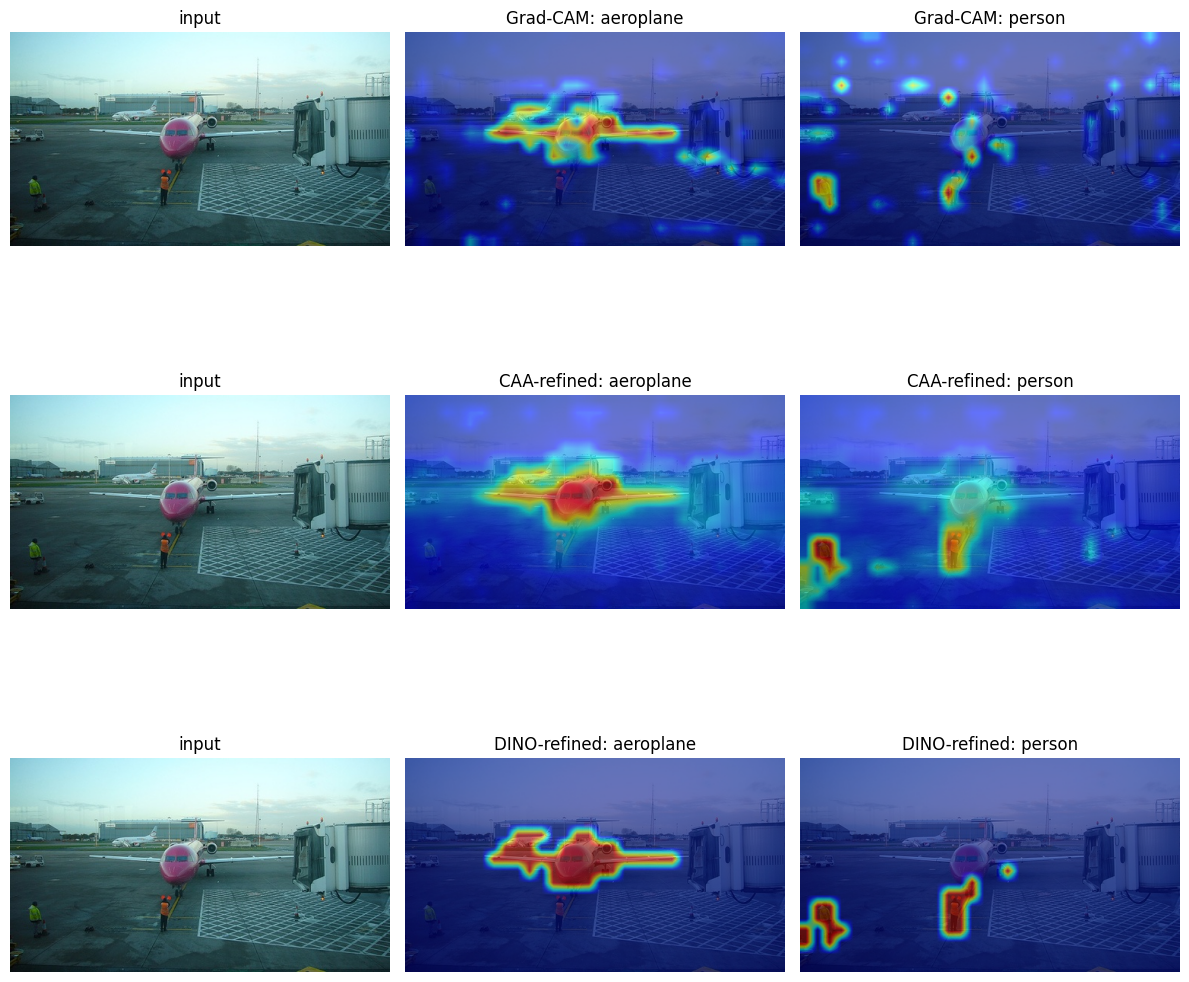

In [ ]:
import torch.nn.functional as F


PATCH_DINO = 16

@torch.no_grad()
def dino_patch_affinity(image_path, h, w, dino_model, device, threshold=0.2):
    """
    Compute patch affinity pairwise matrix.

    We simply take the cosine similarity between the patch tokens of the dino model.
    """
    img = Image.open(image_path)
    x = make_transform((h, w))(img).unsqueeze(0).to(device)

    out = dino_model.forward_features(x)
    tokens = out["x_norm_patchtokens"][0].float()
    tokens = F.normalize(tokens, dim=-1)

    affinity = (tokens @ tokens.T - threshold).clamp(min=0)
    affinity = affinity / (affinity.sum(dim=1, keepdim=True) + 1e-8)
    return affinity


@torch.no_grad()
def dino_refine(result, dino_model, device, cam_threshold=0.5, n_iter=2):
    """
    Mirrors CLIP-ES's CAA step, but uses DINO cosine-affinity
    """
    ori_W, ori_H = result["image_size"]
    h = int(np.ceil(ori_H / PATCH_DINO) * PATCH_DINO)
    w = int(np.ceil(ori_W / PATCH_DINO) * PATCH_DINO)
    gh, gw = h // PATCH_DINO, w // PATCH_DINO
    N = gh * gw

    # Compute the DINO patch affinity once per image.
    affinity = dino_patch_affinity(result["image_path"], h, w, dino_model, device).float()

    refined_cams = {}
    for c, cam_full in result["refined"].items():
        # For each class, take the CAA-refined CAM, downsample it onto the
        #  DINO patch grid, and build an aff_mask = (CAM_norm > cam_threshold).
        cam_grid = cv2.resize(cam_full.astype(np.float32), (gw, gh))
        cam_t = torch.from_numpy(cam_grid).to(device).view(N, 1)

        cam_norm = (cam_grid - cam_grid.min()) / (cam_grid.max() - cam_grid.min() + 1e-8)
        aff_mask_bool = cam_norm > cam_threshold
        if not aff_mask_bool.any():
            aff_mask_bool = cam_norm >= cam_norm.max()
        aff_mask = torch.from_numpy(aff_mask_bool.astype(np.float32)).to(device).view(1, N)

        trans = affinity * aff_mask
        trans = trans / (trans.sum(dim=0, keepdim=True) + 1e-8)
        trans = trans / (trans.sum(dim=1, keepdim=True) + 1e-8)
        for _ in range(n_iter):
            trans = trans / (trans.sum(dim=0, keepdim=True) + 1e-8)
            trans = trans / (trans.sum(dim=1, keepdim=True) + 1e-8)

        
        # random walk 
        trans = (trans + trans.T) / 2
        trans = trans @ trans
        refined = (trans @ cam_t).view(gh, gw).cpu().numpy().astype(np.float32)
        refined_cams[c] = scale_cam_image([refined], (ori_W, ori_H))[0]

    return {**result, "dino_refined": refined_cams}


def show_cams_with_dino(result, alpha=0.55):
    """Side-by-side: input | Grad-CAM | CAA-refined | DINO-refined for each class."""
    img = np.array(Image.open(result["image_path"]).convert("RGB"))
    rows = [
        ("coarse",       "Grad-CAM"),
        ("refined",      "CAA-refined"),
        ("dino_refined", "DINO-refined"),
    ]
    n = len(result["labels"])
    fig, axes = plt.subplots(len(rows), n + 1, figsize=(4 * (n + 1), 4 * len(rows)))
    for r in range(len(rows)):
        axes[r, 0].imshow(img); axes[r, 0].set_title("input"); axes[r, 0].axis("off")
    for i, c in enumerate(result["labels"]):
        for r, (key, label) in enumerate(rows):
            heat = cv2.applyColorMap((result[key][c] * 255).astype(np.uint8), cv2.COLORMAP_JET)
            heat = cv2.cvtColor(heat, cv2.COLOR_BGR2RGB)
            overlay = (alpha * heat + (1 - alpha) * img).clip(0, 255).astype(np.uint8)
            axes[r, i + 1].imshow(overlay)
            axes[r, i + 1].set_title(f"{label}: {new_class_names[c].split(' ')[0]}")
            axes[r, i + 1].axis("off")
    plt.tight_layout(); plt.show()

result_with_dino = dino_refine(result, dino_model, device)
show_cams_with_dino(result_with_dino)

## Step 3: Applying SAM2 to make masks

In [ ]:
SAM_CONFIG     = "configs/sam2.1/sam2.1_hiera_t.yaml"
SAM_CHECKPOINT = "weights/sam2.1_hiera_tiny.pt"

sam_model     = build_sam2(SAM_CONFIG, SAM_CHECKPOINT, device=str(device))
sam_predictor = SAM2ImagePredictor(sam_model)
print("SAM2 ready")

Loading SAM2 (weights/sam2.1_hiera_tiny.pt) on cpu...
SAM2 ready


Running on 2007_000032...
  classes prompted: [0, 14]
  prompt points/class: {0: 2, 14: 3}
  SAM confidences: {0: 0.866, 14: 0.47}


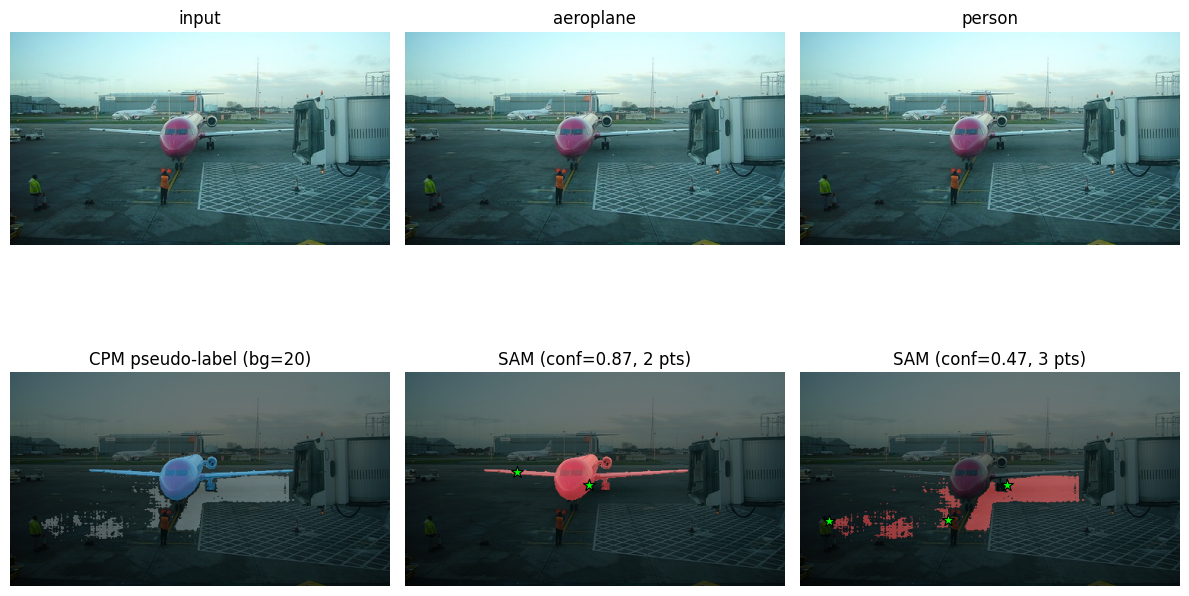

In [ ]:
# To select which points to use for SAM, we use the CPM method.
# view cpm.py for more details.

from cpm import cpm_from_cams

NUM_FG_CLASSES = len(VOC_CLASSES)  # 20 for VOC


def show_cpm(result, cpm_result, alpha=0.55, num_fg_classes=NUM_FG_CLASSES):
    """Visualize the S2C CPM output: input | per-class SAM mask + its prompt
    points | aggregated pseudo-label.

    `num_fg_classes` must match the `num_classes` passed to `cpm_from_cams`,
    so we know which integer in `pgt` represents background.
    """
    img = np.array(Image.open(result["image_path"]).convert("RGB"))
    n = len(result["labels"])

    fig, axes = plt.subplots(2, n + 1, figsize=(4 * (n + 1), 8))
    axes[0, 0].imshow(img); axes[0, 0].set_title("input"); axes[0, 0].axis("off")

    pgt = cpm_result.pgt
    bg_label = num_fg_classes
    pgt_rgb = np.zeros((*pgt.shape, 3), dtype=np.uint8)
    palette = (np.array(plt.get_cmap("tab20").colors) * 255).astype(np.uint8)
    for c in result["labels"]:
        pgt_rgb[pgt == c] = palette[c % len(palette)]
    pgt_overlay = (alpha * pgt_rgb + (1 - alpha) * img).clip(0, 255).astype(np.uint8)
    axes[1, 0].imshow(pgt_overlay)
    axes[1, 0].set_title(f"CPM pseudo-label (bg={bg_label})")
    axes[1, 0].axis("off")

    for i, c in enumerate(result["labels"]):
        mask = cpm_result.masks[c]
        pts = cpm_result.points[c]
        conf = cpm_result.confs[c]

        mask_rgb = np.zeros_like(img)
        mask_rgb[mask] = (255, 64, 64)
        overlay = (0.55 * mask_rgb + 0.45 * img).clip(0, 255).astype(np.uint8)

        axes[0, i + 1].imshow(img)
        axes[0, i + 1].set_title(new_class_names[c].split(" ")[0])
        axes[0, i + 1].axis("off")

        axes[1, i + 1].imshow(overlay)
        axes[1, i + 1].scatter(pts[:, 0], pts[:, 1], s=80, marker="*", c="lime",
                               edgecolors="black", linewidths=0.8)
        axes[1, i + 1].set_title(f"SAM (conf={conf:.2f}, {len(pts)} pts)")
        axes[1, i + 1].axis("off")

    plt.tight_layout()
    plt.show()


def sam_from_cams(
    result,
    predictor,
    source="dino_refined",
    *,
    th_multi=0.5,
    min_distance=20,
    idx_max_sam=2,
    num_classes=NUM_FG_CLASSES,
):
    cpm_out = cpm_from_cams(
        image=result["image_path"],
        cams=result[source],
        predictor=predictor,
        num_classes=num_classes,
        th_multi=th_multi,
        min_distance=min_distance,
        idx_max_sam=idx_max_sam,
    )

    sam_prompts = {
        c: {"points": cpm_out.points[c], "score": cpm_out.confs[c]}
        for c in cpm_out.masks
    }

    return {
        **result,
        "sam_source": source,
        "sam_masks": cpm_out.masks,
        "sam_prompts": sam_prompts,
        "cpm": cpm_out,  # extra: full CPMResult (incl. aggregated pgt) for callers that want it
    }


print(f"Running on {sample_id}...")
cpm_out = cpm_from_cams(
    image=result_with_dino["image_path"],
    cams=result_with_dino["dino_refined"],
    predictor=sam_predictor,
    num_classes=NUM_FG_CLASSES,
    th_multi=0.5,      # S2C default
    min_distance=20,   # S2C default
    idx_max_sam=2,     # S2C "empirically best" largest mask
)

show_cpm(result_with_dino, cpm_out)

## Step 4: mIoU evaluation on VOC 2012 val

evaluation using CLIP-ES's `eval_cam.scores`


In [59]:
from PIL import Image
from tqdm.auto import tqdm
from eval_cam import _fast_hist  # CLIP-ES vendored

VAL_LIST_PATH = os.path.join(CLIP_ES_DIR, "voc12", "val.txt")
SEG_GT_DIR    = os.path.join(VOC_ROOT, "SegmentationClass")
N_CLASS       = 21  # 20 VOC + bg


def load_val_ids(path=VAL_LIST_PATH, subset=None):
    ids = [ln.strip() for ln in open(path) if ln.strip()]
    return ids[:subset] if subset else ids


def predict_per_image(result, source, cam_eval_thres):
    """Per-image (H, W) uint8 prediction in 0..20 (0 = bg).

    Mirrors `clip_es/eval_cam.run_eval_cam`'s inner block:
      - stack per-present-class CAMs into [N_present, H, W]
      - multiply each class CAM by its SAM binary mask (full-pipeline gating)
      - prepend a bg channel (constant `thres` if <1, else (1-max_fg)^thres)
      - argmax + remap local indices through `keys` to global VOC IDs
    """
    keys = np.array(result["labels"], dtype=np.int64)
    cams = np.stack([result[source][c] for c in keys]).astype(np.float32)

    masks = np.stack([result["sam_masks"][c] for c in keys]).astype(np.float32)
    cams = cams * masks

    if cam_eval_thres < 1:
        cams = np.pad(cams, ((1, 0), (0, 0), (0, 0)),
                      mode="constant", constant_values=cam_eval_thres)
    else:
        bg = np.power(1.0 - cams.max(axis=0, keepdims=True), cam_eval_thres)
        cams = np.concatenate([bg, cams], axis=0)

    keys_full = np.pad(keys + 1, (1, 0), mode="constant")  # 0 = bg
    return keys_full[cams.argmax(axis=0)].astype(np.uint8)


def metrics_from_hist(hist):
    """Same formulation as `eval_cam.scores`, but takes an accumulated hist.

    Splitting it out lets us stream per image instead of stockpiling preds.
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        acc      = np.diag(hist).sum() / hist.sum()
        acc_cls  = np.nanmean(np.diag(hist) / hist.sum(axis=1))
        iu       = np.diag(hist) / (hist.sum(axis=1) + hist.sum(axis=0) - np.diag(hist))
        valid    = hist.sum(axis=1) > 0
        mean_iu  = np.nanmean(iu[valid])
        freq     = hist.sum(axis=1) / hist.sum()
        fwavacc  = (freq[freq > 0] * iu[freq > 0]).sum()
    return {
        "Pixel Accuracy":         acc,
        "Mean Accuracy":          acc_cls,
        "Frequency Weighted IoU": fwavacc,
        "Mean IoU":               mean_iu,
        "Class IoU":              dict(zip(range(hist.shape[0]), iu)),
    }


def evaluate(
    val_ids,
    sources=("refined", "dino_refined"),
    cam_eval_thres=2.0,                # CLIP-ES default for "attn"-style refined CAMs
    sam_seed_source="dino_refined",    # which CAM seeds SAM (independent of which CAM scores prediction)
):
    """Run the full pipeline (CLIP-ES → DINO refine → SAM gating) on every image,
    then score every CAM source in `sources` against the GT.
    """
    hists = {s: np.zeros((N_CLASS, N_CLASS), dtype=np.int64) for s in sources}
    skipped = []

    for image_id in tqdm(val_ids, desc="Evaluating"):
        try:
            res = run_clip_es_on_image(image_id)
        except Exception as e:
            skipped.append((image_id, repr(e)))
            continue

        res = dino_refine(res, dino_model, device)
        res = sam_from_cams(res, sam_predictor, source=sam_seed_source)

        gt = np.array(Image.open(os.path.join(SEG_GT_DIR, f"{image_id}.png"))).astype(np.uint8)
        gt_flat = gt.flatten()

        for source in sources:
            pred = predict_per_image(res, source=source, cam_eval_thres=cam_eval_thres)
            hists[source] += _fast_hist(gt_flat, pred.flatten(), N_CLASS)

    if skipped:
        print(f"\nSkipped {len(skipped)} image(s); first few: {skipped[:3]}")

    results = {s: metrics_from_hist(h) for s, h in hists.items()}
    return results, hists


def print_results_table(results, cam_eval_thres):
    """Pretty per-class IoU table, one column per CAM source (always +SAM)."""
    sources = list(results.keys())
    headers = [f"{s}+SAM" for s in sources]
    name_w = max(len(n) for n in (["background"] + VOC_CLASSES))

    print(f"\n=== mIoU report (cam_eval_thres={cam_eval_thres}) ===")
    print("class".ljust(name_w) + " | " + " | ".join(h.center(14) for h in headers))
    print("-" * (name_w + 3 + 17 * len(headers)))
    for c, name in enumerate(["background"] + VOC_CLASSES):
        row = [f"{results[s]['Class IoU'][c]:.4f}".center(14) for s in sources]
        print(name.ljust(name_w) + " | " + " | ".join(row))
    print("-" * (name_w + 3 + 17 * len(headers)))

    for label in ["Mean IoU", "Pixel Accuracy", "Mean Accuracy", "Frequency Weighted IoU"]:
        row = [f"{results[s][label]:.4f}".center(14) for s in sources]
        print(label.ljust(name_w) + " | " + " | ".join(row))


print(f"Found {len(load_val_ids())} val image IDs at {VAL_LIST_PATH}")
print(f"GT segmentation masks at {SEG_GT_DIR}")


Found 1449 val image IDs at /Users/anthony/Code/cs484-wsss/clip_es/voc12/val.txt
GT segmentation masks at data/VOCdevkit/VOC2012/SegmentationClass


In [60]:
# test progess
SUBSET           = 10
CAM_EVAL_THRES   = 2.0

# Always full pipeline (CLIP-ES → DINO refine → SAM gating). The variable here
# is *which* CAM gets multiplied with the SAM masks at scoring time.
SOURCES = [
    "refined",        # CAA-refined CLIP-ES CAM
    "dino_refined",   # + DINO affinity refinement (best CAM stage)
]

val_ids = load_val_ids(subset=SUBSET)
results, hists = evaluate(
    val_ids,
    sources=SOURCES,
    cam_eval_thres=CAM_EVAL_THRES,
)
print_results_table(results, CAM_EVAL_THRES)


Evaluating 10 images across 2 CAM sources...


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]


=== mIoU report (cam_eval_thres=2.0) ===
class       |  refined+SAM   | dino_refined+SAM
------------------------------------------------
background  |     0.8482     |     0.8412    
aeroplane   |     0.8312     |     0.8181    
bicycle     |     0.7113     |     0.7502    
bird        |      nan       |      nan      
boat        |     0.7624     |     0.8034    
bottle      |     0.9911     |     0.9906    
bus         |      nan       |      nan      
car         |      nan       |      nan      
cat         |      nan       |      nan      
chair       |      nan       |      nan      
cow         |      nan       |      nan      
diningtable |      nan       |      nan      
dog         |      nan       |      nan      
horse       |     0.9621     |     0.8446    
motorbike   |      nan       |      nan      
person      |     0.3989     |     0.3790    
pottedplant |      nan       |      nan      
sheep       |     0.9426     |     0.8904    
sofa        |      nan       |   

## Step 5: Qualitative samples

The aggregate mIoU table tells you *what* — these picked-out samples tell you
*why*. We re-run the pipeline on a small pool, score each image per-config,
and bucket by behavior:

  * **biggest SAM wins** — refined CAM was OK, SAM gating snapped it to a
    much tighter mask
  * **biggest SAM regressions** — SAM hijacked the prompt onto the wrong
    object (the failure mode we saw with the airport `person` mask)
  * **best across all configs** — easy images, every refinement stage agrees
  * **worst across all configs** — hard images, nothing works (small/occluded
    objects, multi-instance, etc.)

The result is the figures you'd put in a writeup to explain the table.


In [ ]:
def _voc_colormap(N=256):
    """Standard PASCAL VOC palette (matches torchvision's GT PNGs)."""
    cmap = np.zeros((N, 3), dtype=np.uint8)
    for i in range(N):
        r = g = b = 0
        c = i
        for j in range(8):
            r |= ((c >> 0) & 1) << (7 - j)
            g |= ((c >> 1) & 1) << (7 - j)
            b |= ((c >> 2) & 1) << (7 - j)
            c >>= 3
        cmap[i] = (r, g, b)
    return cmap

VOC_PALETTE = _voc_colormap()


def _colorize(mask):
    """(H, W) class-index mask -> (H, W, 3) uint8 RGB via VOC palette."""
    return VOC_PALETTE[mask]


def per_image_pipeline(image_id, sources, cam_eval_thres=2.0,
                       sam_seed_source="dino_refined"):
    """Run CLIP-ES + DINO + SAM on one image, score every CAM source.

    Returns (result, gt, preds_by_source, ious_by_source). `ious` is per-image
    mIoU (i.e. metrics_from_hist applied to the single-image confusion
    histogram), which is the right scalar for ranking samples.
    """
    res = run_clip_es_on_image(image_id)
    res = dino_refine(res, dino_model, device)
    res = sam_from_cams(res, sam_predictor, source=sam_seed_source)

    gt = np.array(Image.open(os.path.join(SEG_GT_DIR, f"{image_id}.png"))).astype(np.uint8)
    gt_flat = gt.flatten()

    preds, ious = {}, {}
    for source in sources:
        pred = predict_per_image(res, source=source, cam_eval_thres=cam_eval_thres)
        h = _fast_hist(gt_flat, pred.flatten(), N_CLASS)
        preds[source] = pred
        ious[source]  = metrics_from_hist(h)["Mean IoU"]
    return res, gt, preds, ious


def pick_interesting_samples(val_ids, sources, k=2, **pipeline_kwargs):
    """Run pipeline on each id, bucket the results by behavior, return top-k per bucket."""
    rows = []
    for image_id in tqdm(val_ids, desc="Scoring for sample picking"):
        try:
            res, gt, preds, ious = per_image_pipeline(image_id, sources, **pipeline_kwargs)
        except Exception:
            continue
        rows.append({"id": image_id, "res": res, "gt": gt, "preds": preds, "ious": ious})

    if not rows:
        return {}

    buckets = {}
    # If we're comparing the two refinement stages, surface where DINO refinement
    # helps vs hurts the most (the new analog of the old SAM win/regress buckets).
    if "refined" in sources and "dino_refined" in sources:
        for r in rows:
            r["delta"] = r["ious"]["dino_refined"] - r["ious"]["refined"]
        buckets["biggest DINO refinement wins"]        = sorted(rows, key=lambda r: -r["delta"])[:k]
        buckets["biggest DINO refinement regressions"] = sorted(rows, key=lambda r:  r["delta"])[:k]
    buckets["best across all sources"]  = sorted(rows, key=lambda r: -min(r["ious"].values()))[:k]
    buckets["worst across all sources"] = sorted(rows, key=lambda r:  max(r["ious"].values()))[:k]
    return buckets


def show_sample_comparison(buckets, sources, alpha=0.55):
    """One figure per bucket. Rows = sampled images, cols = input | GT | sources..."""
    n_cols = 2 + len(sources)
    headers = ["input", "ground truth"] + [f"{s}+SAM" for s in sources]

    for bucket_name, samples in buckets.items():
        if not samples:
            continue
        n_rows = len(samples)
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(3.2 * n_cols, 3.0 * n_rows + 0.3))
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        fig.suptitle(bucket_name, fontsize=15, fontweight="bold", y=1.0)

        for r, s in enumerate(samples):
            img = np.array(Image.open(s["res"]["image_path"]).convert("RGB"))

            cells = [img]
            cells.append((alpha * _colorize(s["gt"]) + (1 - alpha) * img).clip(0, 255).astype(np.uint8))
            for source in sources:
                pred_rgb = _colorize(s["preds"][source])
                cells.append((alpha * pred_rgb + (1 - alpha) * img).clip(0, 255).astype(np.uint8))

            for c, cell in enumerate(cells):
                axes[r, c].imshow(cell)
                axes[r, c].axis("off")
                if c == 0:
                    title = s["id"]
                elif c == 1:
                    title = headers[c]
                else:
                    source = sources[c - 2]
                    title = f"{headers[c]}\nIoU={s['ious'][source]:.3f}"
                axes[r, c].set_title(title, fontsize=9)

        plt.tight_layout()
        plt.show()


# Re-uses SOURCES / CAM_EVAL_THRES from the eval cell.
# Pool of 50 takes about as long as the sanity eval (we re-run the pipeline
# to score per-image; cheap to make smaller, just less variety to bucket from).
SAMPLE_POOL_SIZE = 50
sample_buckets = pick_interesting_samples(
    load_val_ids(subset=SAMPLE_POOL_SIZE),
    sources=SOURCES,
    k=2,
    cam_eval_thres=CAM_EVAL_THRES,
)
show_sample_comparison(sample_buckets, SOURCES)
